In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np
import pathlib
import seaborn as sns
from scipy.stats import skew, kurtosis

In [6]:
manifest_path = "/Users/furkan/projects/mebar-radiology/data/manifest.csv"
manifest_df = pd.read_csv(manifest_path)
manifest_df = manifest_df.set_index("sample_id")

## Intensity Distribution

Statistics on intensity.

In [8]:
def get_abs_path(relative_path):
    root_dir = pathlib.Path.cwd().parent
    return root_dir / relative_path

def _extract_statistics(values):

	percentiles = np.percentile(
		values,
		[1, 5, 25, 50, 75, 95, 99]
	)

	p01, p05, p25, p50, p75, p95, p99 = percentiles

	return {
            "count": len(values),
			"min": values.min(),
			"max": values.max(),
            "mean": values.mean(),
            "std": values.std(),
           	"p01": p01,
            "p05": p05,
            "p25": p25,
            "p50": p50,
            "p75": p75,
            "p95": p95,
            "p99": p99,
            "iqr": p75-p25,
            "skewness": skew(values),
            "kurtosis": kurtosis(values),
        }

def statistics(sample_id):
	row = manifest_df.loc[sample_id]
	mask_path = get_abs_path(row["mask_path"])
	img_path = get_abs_path(row["image_path"])

	image = sitk.ReadImage(img_path)
	mask = sitk.ReadImage(mask_path)

	image_array = sitk.GetArrayFromImage(image)
	mask_array = sitk.GetArrayFromImage(mask)

	if image_array.shape != mask_array.shape:
		raise ValueError(
			f"Shape mismatch: {row['sample_id']}"
		)

	# maps invalid voxels to 0, valids to 1
	finite = np.isfinite(image_array)

	foreground = finite & (image_array != 0) & (image_array != -256)
	tumor = finite & (mask_array != 0)

	foreground_results = _extract_statistics(image_array[foreground])

	tumor_results = _extract_statistics(image_array[tumor])

	return (
		foreground_results,
		tumor_results
	)


In [11]:
# mask - image shape and origin mismatch causes fail

rows = []
failed = []

for sample_id, row in manifest_df.iterrows():
    try:
        foreground_results, tumor_results = statistics(sample_id)

        rows.append({
            "sample_id": sample_id,
            "modality": row["modality"],
            "response_group": row["response_group"],
            "batch_id":row["batch_id"],
            **{f"foreground_{k}": v for k, v in foreground_results.items()},
            **{f"tumor_{k}": v for k, v in tumor_results.items()},
        })

    except Exception as e:
        print(f"sample with id {sample_id} failed: {e}")
        failed.append(sample_id)

results_df = pd.DataFrame(rows)

sample with id 2fa95f062483ba1b failed: 'sample_id'


In [13]:
pd.set_option('display.max_columns', None)
results_df.describe()

,foreground_count,foreground_mean,foreground_std,foreground_p01,foreground_p05,foreground_p25,foreground_p50,foreground_p75,foreground_p95,foreground_p99,foreground_iqr,foreground_skewness,foreground_kurtosis,tumor_count,tumor_mean,tumor_std,tumor_p01,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis
count,3.750000e+02,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000
mean,3.478967e+06,566.002573,395.333535,24.592015,70.273352,242.233459,508.586037,816.206965,1288.148494,1665.748134,573.973506,0.630237,0.181025,19115.232000,624.704324,136.127388,359.335606,427.110410,528.696767,612.752463,707.975776,863.785569,988.280441,179.279009,0.571405,1.139291
std,4.177432e+06,361.747165,249.537137,56.844842,96.647534,202.852936,340.186356,481.517937,864.345452,1147.935004,323.136824,0.546448,1.581461,33789.705157,491.053266,121.094582,292.806187,336.766242,414.192163,485.785939,564.550969,684.568794,769.746795,176.829676,0.457384,1.690465
min,1.759790e+05,0.383890,0.340561,-1.000000,-1.000000,-1.000000,-0.001284,0.680002,1.135584,1.473008,0.475407,-0.580912,-1.578898,113.000000,0.655809,0.123612,0.354491,0.478975,0.555897,0.611011,0.701017,0.996293,1.264807,0.145120,-0.821629,-1.626945
25%,7.716515e+05,276.783473,189.240848,3.000000,6.500000,78.000000,245.000000,438.000000,569.000000,651.000000,337.500000,0.194354,-1.139257,1657.000000,225.148937,44.874883,121.500000,151.000000,192.500000,222.500000,254.250000,309.500000,353.000000,54.000000,0.290220,0.220699
50%,2.287071e+06,553.237676,397.947301,16.000000,53.000000,213.000000,465.000000,813.000000,1264.000000,1597.279121,559.000000,0.591302,-0.494965,5335.000000,584.812500,107.967894,326.000000,402.000000,499.094505,571.142857,652.984615,799.200000,921.000000,134.250000,0.538294,0.878374
75%,4.088560e+06,833.590968,575.182047,31.000000,99.000000,358.000000,743.500000,1171.580464,1874.500000,2668.000000,803.500000,0.994986,1.355022,21382.000000,932.361527,194.928410,543.040000,635.777198,788.000000,896.000000,1046.500000,1273.025000,1462.830000,251.875000,0.838947,1.527635
max,2.036338e+07,1854.572989,1209.090218,952.000000,1289.000000,1367.000000,1864.000000,2726.000000,4095.000000,4323.000000,2290.000000,2.559780,6.895771,373100.000000,2689.494361,728.061613,1865.000000,2070.800000,2409.000000,2696.000000,2976.000000,3527.500000,3901.060000,1391.500000,2.992540,18.038977


**ATTENTION!** sample 14 seems quite abnormal. It seems like imaging scaled very differently from others, might be related to batch, if different batches generated by different machines. Check if there are other samples like them, **scaled in very small values**:

In [12]:
# detect small scaled samples
adc_results = results_df[
    results_df["modality"] == "ADC"
].copy()

adc_results["scale_group"] = np.where(
    adc_results["foreground_p99"] < 10,
    "small_scale",
    "large_scale"
)

adc_results["scale_group"].value_counts()

scale_group
large_scale    165
small_scale     22
Name: count, dtype: int64

In [15]:
adc_results.head()

,sample_id,modality,response_group,batch_id,foreground_count,foreground_min,foreground_max,foreground_mean,foreground_std,foreground_p01,foreground_p05,foreground_p25,foreground_p50,foreground_p75,foreground_p95,foreground_p99,foreground_iqr,foreground_skewness,foreground_kurtosis,tumor_count,tumor_min,tumor_max,tumor_mean,tumor_std,tumor_p01,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis,scale_group
0,0d6f73a01539ae0d,ADC,intermediate,batch-1,1046394,1,3366,591.813602,396.192293,31.0,95.0,289.0,514.0,843.0,1264.0,1901.0,554.0,1.165774,2.284802,468,318,1375,787.508547,193.051524,414.05,501.0,653.75,769.0,899.75,1141.95,1265.28,246.0,0.386208,-0.125492,large_scale
2,c5574c732708c9c0,ADC,intermediate,batch-1,494151,1,3258,1165.514936,881.324863,20.0,94.0,484.0,952.0,1507.0,2822.0,2941.0,1023.0,0.774423,-0.612221,5473,294,2237,1025.752238,277.843604,436.44,622.2,826.00,988.0,1214.00,1510.00,1744.00,388.0,0.436529,0.093765,large_scale
4,85e3e9f712fe9029,ADC,intermediate,batch-1,841097,1,3540,626.175353,440.623986,28.0,90.0,285.0,532.0,903.0,1400.0,2065.0,618.0,1.157507,1.861547,376,394,1161,640.813830,128.031298,435.50,474.0,544.75,620.5,708.75,872.00,1039.00,164.0,0.895243,0.878374,large_scale
6,6d382c4f0f97ffa6,ADC,intermediate,batch-1,661507,1,3855,1282.197046,675.943923,53.0,217.0,861.0,1273.0,1596.0,2882.0,3108.0,735.0,0.619839,0.663824,1422,522,1605,899.811533,170.169613,613.00,680.0,783.00,862.0,989.00,1237.95,1366.95,206.0,0.937927,0.807619,large_scale
8,c650692054c62b07,ADC,intermediate,batch-1,793725,5,3286,658.127508,397.407783,34.0,102.0,331.0,646.0,932.0,1256.0,1888.0,601.0,0.751565,1.364345,599,356,1013,669.312187,107.457789,464.82,506.9,593.00,660.0,737.50,859.00,964.06,144.5,0.453230,0.218035,large_scale


In [24]:
adc_info = adc_results.merge(
    manifest_df[
        [
            "batch_id",
            "image_dtype",
            "image_encoding",
            "response_group"
        ]
    ],
    left_on="sample_id",
    right_index=True,
    how="left",
    suffixes=("", "_manifest")
)

pd.crosstab(
    adc_info["batch_id"],
    adc_info["scale_group"],
    margins=True
)

scale_group,large_scale,small_scale,All
batch_id,,,
batch-1,88,11,99
batch-2,77,11,88
All,165,22,187


Not related to batch, appearently. But there are 22 total small scaled imagings. **Small scaled and large scaled imagings min-max intensities are x1000 different, seemingly (intuitive)**. Check if large scaled imagings are really large scaled.

/var/folders/4j/vmfcbk011r1d4ztywrf3d_rh0000gn/T/ipykernel_53126/2662021131.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


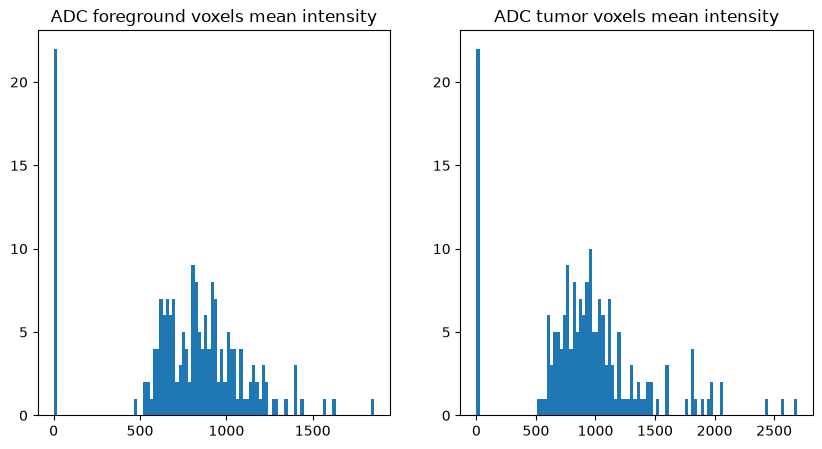

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(adc_results["foreground_mean"], bins=100)
axes[0].set_title("ADC foreground voxels mean intensity")

axes[1].hist(adc_results["tumor_mean"], bins=100)
axes[1].set_title("ADC tumor voxels mean intensity")
fig.show()

/var/folders/4j/vmfcbk011r1d4ztywrf3d_rh0000gn/T/ipykernel_46052/595126451.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


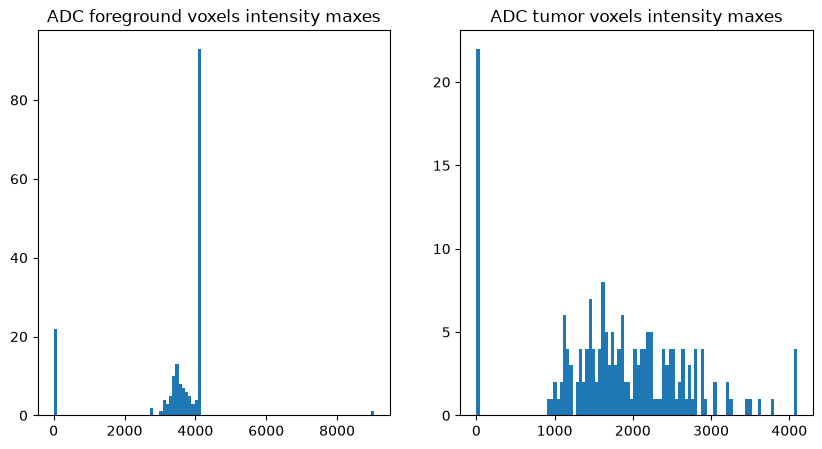

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(adc_results["foreground_max"], bins=100)
axes[0].set_title("ADC foreground voxels intensity maxes")

axes[1].hist(adc_results["tumor_max"], bins=100)
axes[1].set_title("ADC tumor voxels intensity maxes")
fig.show()

Histogram strengthens the 1000x scale difference assumption between ADC imagings. 1000 is not certain, but ~1000 times scale difference is clear now. Now we should detect the number precisely, if approx. medians are ~1000 times scaled, we might assume so.

In [18]:
adc_info.groupby("scale_group")["tumor_p50"].median()

scale_group
large_scale    919.000000
small_scale      0.931219
Name: tumor_p50, dtype: float64

We have a very strong indicator of a scale difference. We should consider this when preprocessing data, possibly rescaling small scaled samples by 1000x.
<br>**Below is how data would seem like if small scaled samples rescaled 1000x:**

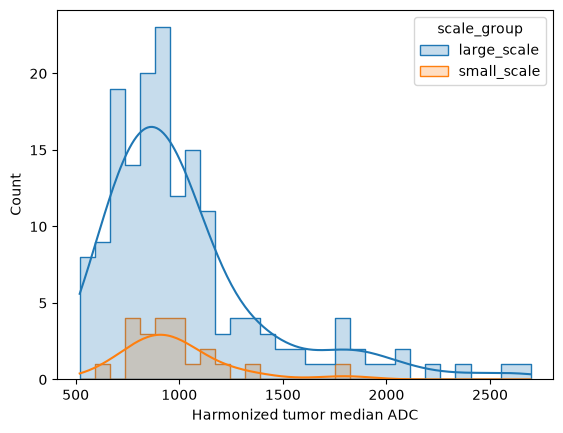

In [19]:
adc_info["corrected_tumor_p50"] = np.where(
    adc_info["scale_group"] == "small_scale",
    adc_info["tumor_p50"] * 1000,
    adc_info["tumor_p50"]
)

sns.histplot(
    data=adc_info,
    x="corrected_tumor_p50",
    hue="scale_group",
    bins=30,
    kde=True,
    element="step",
    common_norm=False
)

plt.xlabel("Harmonized tumor median ADC")
plt.show()

Our assumptions seem correct. Almost perfectly fits when small scaled ones scales by 1000x. Just to make sure, also check other percentiles:

In [20]:
adc_info.groupby("scale_group").agg(
    count=("corrected_tumor_p50", "count"),
    median=("corrected_tumor_p50", "median"),
    q25=("corrected_tumor_p50", lambda x: x.quantile(0.25)),
    q75=("corrected_tumor_p50", lambda x: x.quantile(0.75)),
    mean=("corrected_tumor_p50", "mean"),
)

,count,median,q25,q75,mean
scale_group,,,,,
large_scale,165,919.000000,769.000000,1117.500000,1027.712121
small_scale,22,931.219268,844.024247,1030.448046,978.114166


In [21]:
group_medians = adc_info.groupby("scale_group")["tumor_p50"].median()

ratio = (
    group_medians["large_scale"]
    / group_medians["small_scale"]
)

print("Scale ratio:", ratio)

Scale ratio: 986.8782050834429


## Intensity vs Labels (T2)

In [22]:
t2_df = results_df[results_df["modality"] == "T2"]

Raw (not normalized yet) plot:

Text(0.5, 1.0, 'T2 p75 intensity vs labels')

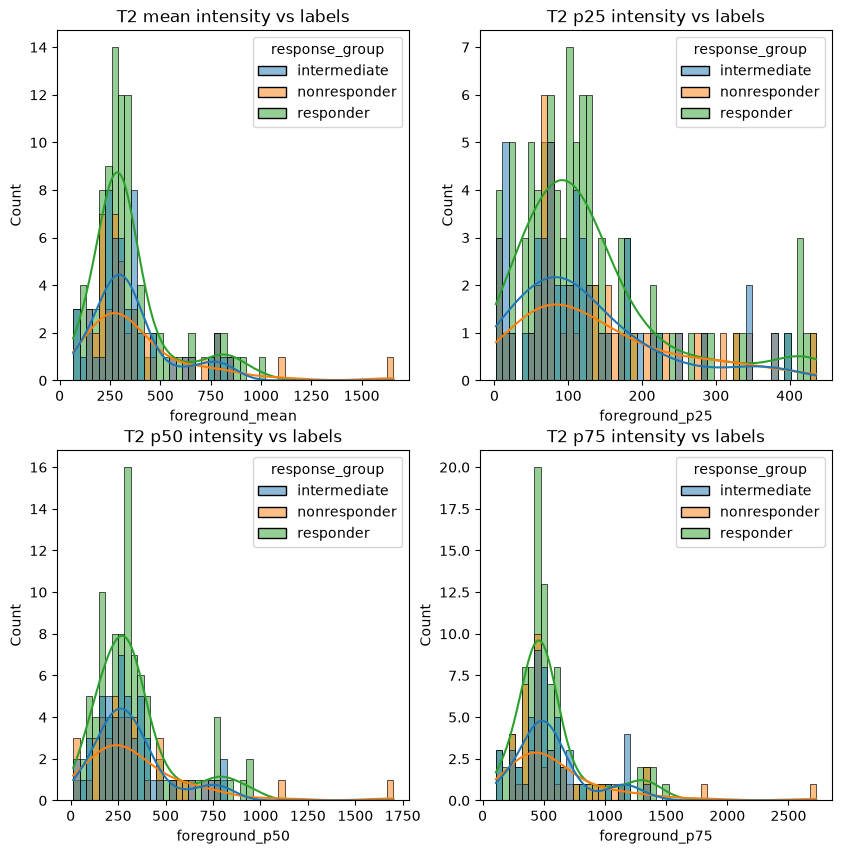

In [23]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=t2_df,
	x="foreground_mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=50
)
axes[0][0].set_title("T2 mean intensity vs labels")

sns.histplot(
	data=t2_df,
	x="foreground_p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=50
)
axes[0][1].set_title("T2 p25 intensity vs labels")

sns.histplot(
	data=t2_df,
	x="foreground_p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=50
)
axes[1][0].set_title("T2 p50 intensity vs labels")

sns.histplot(
	data=t2_df,
	x="foreground_p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=50
)
axes[1][1].set_title("T2 p75 intensity vs labels")

After normalization:

In [1]:
def z_score_normalize(image):
	image_array = sitk.GetArrayFromImage(image).astype(np.float32)
	finite = np.isfinite(image_array)

	body_mask = (
		finite
	)

	values = image_array[body_mask]

	# limiting radical values
	lower, upper = np.percentile(values, [1, 99])
	clipped = np.clip(image_array, lower, upper)

	mean = clipped[body_mask].mean()
	std = clipped[body_mask].std()
	
	normalized = (clipped - mean) / std
	normalized[~body_mask] = 0

	normalized_image = sitk.GetImageFromArray(normalized)
	# copy origin, spacing and direction information from original image
	normalized_image.CopyInformation(image)

	return normalized_image

I will recreate the whole dataset only z score normalized for now, after creating the graph I will delete all. 

In [2]:
import os
os.makedirs("no_mask", exist_ok=True)

In [ ]:
manifest_t2_df = manifest_df[manifest_df["modality"] == "T2"]

for sample_id, row in manifest_t2_df.iterrows():
	image_path = get_abs_path(row["image_path"])
	image = sitk.ReadImage(image_path)
	exp_image = z_score_normalize(image)
	sitk.WriteImage(exp_image, f"no_mask/{row["patient_name"]}_{row["modality"]}.nrrd")

Feed the normalized images into statistics function:

In [27]:
def statistics(image_path):
	image = sitk.ReadImage(image_path)
	image_array = sitk.GetArrayFromImage(image)

	# maps invalid voxels to 0, valids to 1
	finite = np.isfinite(image_array)

	foreground = finite & (image_array != 0) & (image_array != -256)

	results = _extract_statistics(image_array[foreground])

	return results


In [28]:
def files_list(hedef_klasor: str) -> list[str]:
    from pathlib import Path
    return [
        str(dosya.resolve())
        for dosya in Path(hedef_klasor).rglob("*")
        if dosya.is_file()
    ]

In [29]:
# mask - image shape and origin mismatch causes fail
rows = []
failed = []

file_list = files_list("no_mask")
for idx in range(len(file_list)):
    try:
        foreground_results = statistics(file_list[idx])

        rows.append({
            "sample_id": sample_id,
            "modality": manifest_t2_df.iloc[idx]["modality"],
            "response_group": manifest_t2_df.iloc[idx]["response_group"],
            "batch_id":manifest_t2_df.iloc[idx]["batch_id"],
            **{f"{k}": v for k, v in foreground_results.items()}
        })

    except Exception as e:
        print(f"sample with id {sample_id} failed: {e}")
        failed.append(sample_id)

results_df = pd.DataFrame(rows)

In [30]:
results_df.head()

,sample_id,modality,response_group,batch_id,count,min,max,mean,std,p01,p05,p25,p50,p75,p95,p99,iqr,skewness,kurtosis
0,1478bad561f917ed,T2,intermediate,batch-1,8294400,-0.621353,2.813612,-2.543918e-17,1.0,-0.621353,-0.621353,-0.621353,-0.621353,0.297236,2.290295,2.813612,0.918589,1.466090,0.760509
1,1478bad561f917ed,T2,intermediate,batch-1,14625792,-1.564042,2.334244,-3.581816e-17,1.0,-1.564042,-1.373537,-0.826719,-0.212871,0.870182,1.667478,2.334244,1.696901,0.388296,-0.952916
2,1478bad561f917ed,T2,intermediate,batch-1,8294400,-0.795289,2.142408,-3.508853e-18,1.0,-0.795289,-0.795289,-0.795289,-0.755828,0.914714,1.844254,2.142408,1.710003,0.820672,-0.936108
3,1478bad561f917ed,T2,intermediate,batch-1,2822400,-1.457503,1.832842,7.218212e-17,1.0,-1.457503,-1.414632,-0.985923,-0.042762,0.953988,1.468439,1.832842,1.939911,0.082012,-1.447129
4,1478bad561f917ed,T2,intermediate,batch-1,21667840,-1.091591,2.911844,-8.059086e-17,1.0,-1.091591,-1.091591,-0.865064,-0.246470,0.707559,1.853264,2.911844,1.572622,0.779364,-0.270506


Text(0.5, 1.0, 'T2 p75 intensity vs labels')

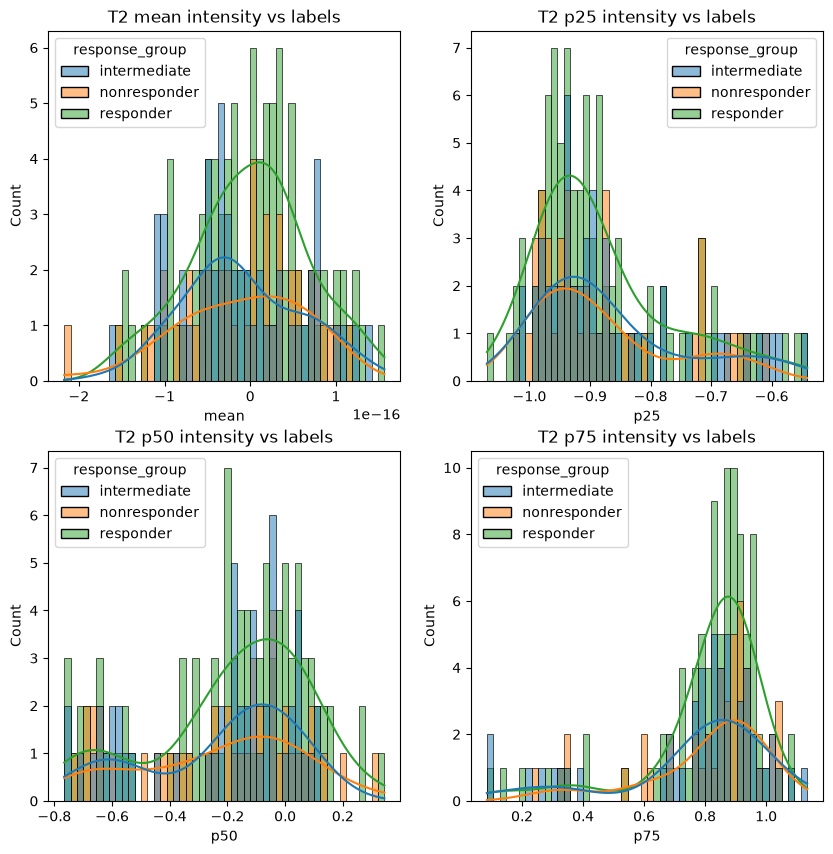

In [31]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=results_df,
	x="mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=50
)
axes[0][0].set_title("T2 mean intensity vs labels")

sns.histplot(
	data=results_df,
	x="p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=50
)
axes[0][1].set_title("T2 p25 intensity vs labels")

sns.histplot(
	data=results_df,
	x="p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=50
)
axes[1][0].set_title("T2 p50 intensity vs labels")

sns.histplot(
	data=results_df,
	x="p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=50
)
axes[1][1].set_title("T2 p75 intensity vs labels")

## Intensity vs Labels (ADC)

Only small scaled:

In [21]:
small_scaled_results_df = adc_results[adc_results["scale_group"] == "small_scale"]
small_scaled_results_df.head()

,sample_id,modality,response_group,batch_id,foreground_count,foreground_min,foreground_max,foreground_mean,foreground_std,foreground_p01,...,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis,scale_group
14,6da62ba89f121b65,ADC,intermediate,batch-1,787968,-0.432499,1.818855,0.862208,0.654879,-0.179050,...,0.822212,0.984012,1.120083,1.318554,1.547153,1.748406,0.334542,0.486863,-0.178933,small_scale
43,003da9c17d67938b,ADC,intermediate,batch-1,725760,-0.432499,1.818855,0.940643,0.654871,-0.264266,...,0.829084,0.922437,1.034867,1.188256,1.365945,1.447665,0.265819,0.384463,-0.671723,small_scale
49,f2ee2155e8541645,ADC,intermediate,batch-1,725760,-0.432499,1.818855,0.745385,0.626001,-0.258218,...,0.531268,0.683969,0.761901,0.869933,1.087591,1.312671,0.185963,0.721686,1.326664,small_scale
53,34457c052fa53b67,ADC,intermediate,batch-1,276480,-1.458615,3.367249,0.586931,0.544458,-0.343226,...,0.614710,0.805848,0.951822,1.089686,1.344953,1.515580,0.283838,0.274678,0.126934,small_scale
63,580736da8ab3d87a,ADC,nonresponder,batch-1,183198,0.000538,2.202749,0.910705,0.453473,0.054867,...,0.835646,0.944304,1.017191,1.097609,1.241769,1.367372,0.153305,0.446392,0.388231,small_scale


Text(0.5, 1.0, 'ADC (small scaled) p75 intensity vs labels')

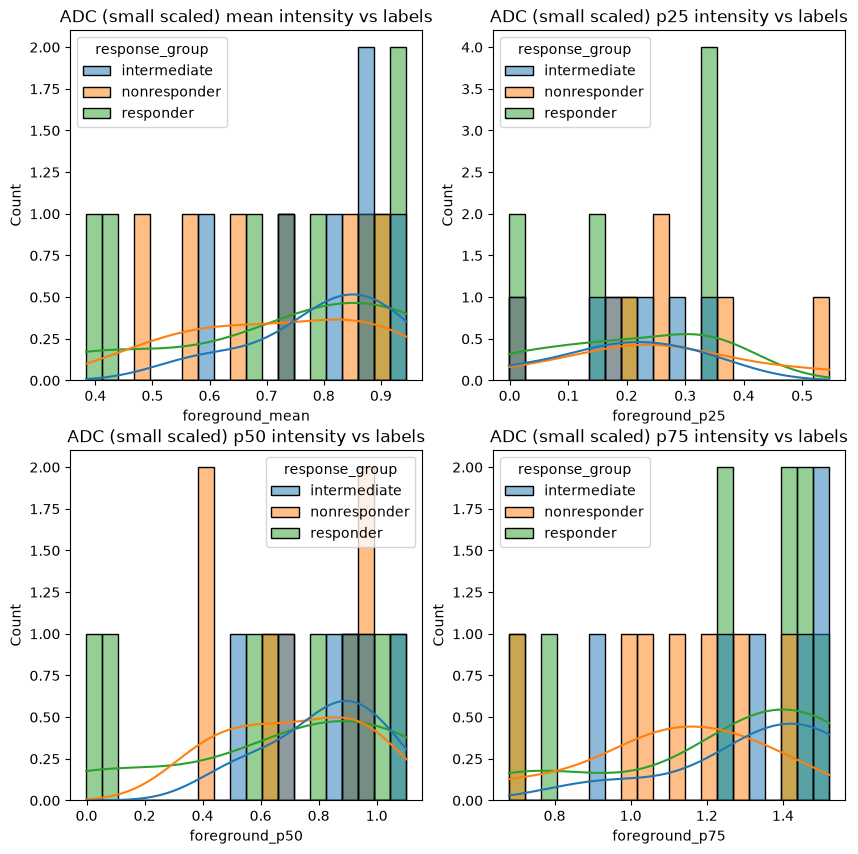

In [17]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=small_scaled_results_df,
	x="foreground_mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=20
)
axes[0][0].set_title("ADC (small scaled) mean intensity vs labels")

sns.histplot(
	data=small_scaled_results_df,
	x="foreground_p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=20
)
axes[0][1].set_title("ADC (small scaled) p25 intensity vs labels")

sns.histplot(
	data=small_scaled_results_df,
	x="foreground_p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=20
)
axes[1][0].set_title("ADC (small scaled) p50 intensity vs labels")

sns.histplot(
	data=small_scaled_results_df,
	x="foreground_p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=20
)
axes[1][1].set_title("ADC (small scaled) p75 intensity vs labels")

In [22]:
small_scaled_results_df.describe()

,foreground_count,foreground_mean,foreground_std,foreground_p01,foreground_p05,foreground_p25,foreground_p50,foreground_p75,foreground_p95,foreground_p99,...,tumor_p01,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis
count,2.200000e+01,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,...,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,8.233159e+05,0.752231,0.599944,-0.272034,-0.044926,0.217960,0.729334,1.228621,1.718029,1.947872,...,0.549716,0.668052,0.842768,0.978114,1.138677,1.395302,1.572808,0.295909,0.580274,0.913377
std,5.784178e+05,0.171273,0.083150,0.177952,0.097793,0.141744,0.297593,0.263723,0.180645,0.357836,...,0.134272,0.146205,0.194499,0.251885,0.297539,0.311737,0.280305,0.120938,0.568802,1.889590
min,1.831980e+05,0.383890,0.340561,-0.720090,-0.251162,-0.001284,-0.001284,0.680002,1.135584,1.473008,...,0.354491,0.478975,0.555897,0.611011,0.701017,0.996293,1.264807,0.145120,-0.371095,-0.802185
25%,7.257600e+05,0.649697,0.577263,-0.348743,-0.089710,0.141885,0.591334,1.072598,1.644831,1.818855,...,0.446231,0.582432,0.716956,0.844024,0.997822,1.246259,1.371837,0.216614,0.310829,-0.297842
50%,7.257600e+05,0.812669,0.626291,-0.261242,-0.000371,0.212069,0.814680,1.283368,1.818855,1.818855,...,0.511638,0.637776,0.798031,0.931219,1.065930,1.327625,1.486037,0.270018,0.588935,0.165004
75%,7.257600e+05,0.873012,0.647543,-0.176163,-0.000371,0.333209,0.939617,1.439781,1.818855,1.818855,...,0.653730,0.741621,0.938837,1.030448,1.244231,1.503610,1.801181,0.323409,0.706621,1.140669
max,2.508800e+06,0.944638,0.696381,0.054867,0.162449,0.545980,1.102490,1.521423,1.835485,3.219552,...,0.814878,1.079359,1.463912,1.798165,2.085363,2.356335,2.478029,0.621451,2.132514,6.598212


Only large scaled:

In [19]:
large_scaled_results_df = adc_results[adc_results["scale_group"] == "large_scale"]
large_scaled_results_df.head()

,sample_id,modality,response_group,batch_id,foreground_count,foreground_min,foreground_max,foreground_mean,foreground_std,foreground_p01,...,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis,scale_group
0,0d6f73a01539ae0d,ADC,intermediate,batch-1,1046394,1,3366,591.813602,396.192293,31.0,...,501.0,653.75,769.0,899.75,1141.95,1265.28,246.0,0.386208,-0.125492,large_scale
2,c5574c732708c9c0,ADC,intermediate,batch-1,494151,1,3258,1165.514936,881.324863,20.0,...,622.2,826.00,988.0,1214.00,1510.00,1744.00,388.0,0.436529,0.093765,large_scale
4,85e3e9f712fe9029,ADC,intermediate,batch-1,841097,1,3540,626.175353,440.623986,28.0,...,474.0,544.75,620.5,708.75,872.00,1039.00,164.0,0.895243,0.878374,large_scale
6,6d382c4f0f97ffa6,ADC,intermediate,batch-1,661507,1,3855,1282.197046,675.943923,53.0,...,680.0,783.00,862.0,989.00,1237.95,1366.95,206.0,0.937927,0.807619,large_scale
8,c650692054c62b07,ADC,intermediate,batch-1,793725,5,3286,658.127508,397.407783,34.0,...,506.9,593.00,660.0,737.50,859.00,964.06,144.5,0.453230,0.218035,large_scale


Text(0.5, 1.0, 'ADC (large scaled) p75 intensity vs labels')

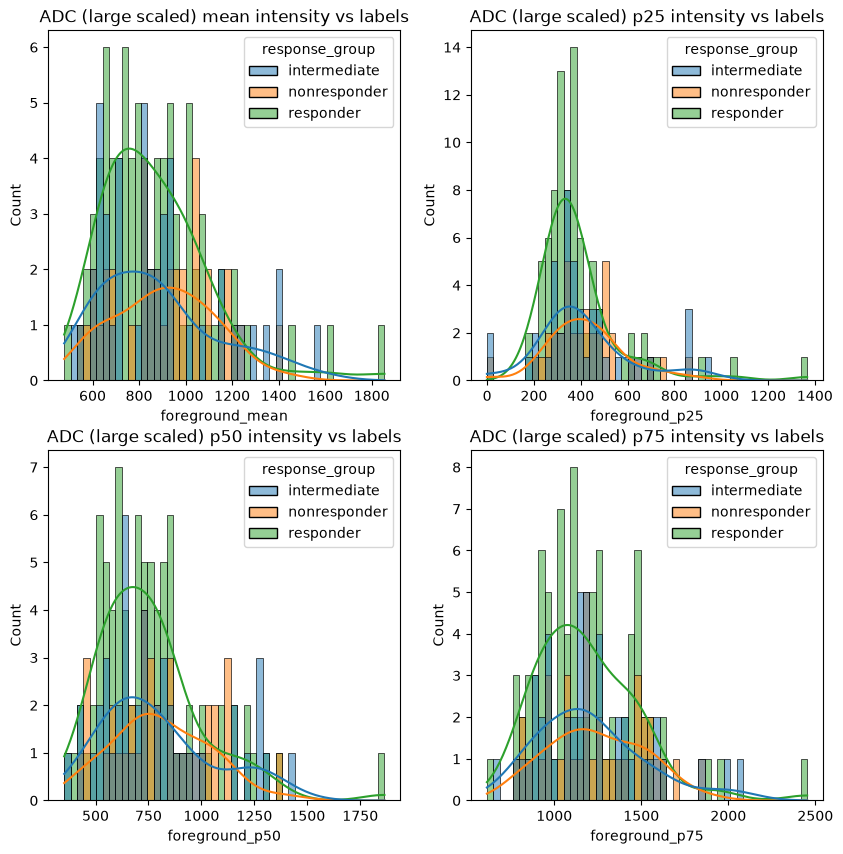

In [35]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=large_scaled_results_df,
	x="foreground_mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=50
)
axes[0][0].set_title("ADC (large scaled) mean intensity vs labels")

sns.histplot(
	data=large_scaled_results_df,
	x="foreground_p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=50
)
axes[0][1].set_title("ADC (large scaled) p25 intensity vs labels")

sns.histplot(
	data=large_scaled_results_df,
	x="foreground_p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=50
)
axes[1][0].set_title("ADC (large scaled) p50 intensity vs labels")

sns.histplot(
	data=large_scaled_results_df,
	x="foreground_p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=50
)
axes[1][1].set_title("ADC (large scaled) p75 intensity vs labels")

In [20]:
large_scaled_results_df.describe()

,foreground_count,foreground_mean,foreground_std,foreground_p01,foreground_p05,foreground_p25,foreground_p50,foreground_p75,foreground_p95,foreground_p99,...,tumor_p01,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis
count,1.650000e+02,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,...,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,9.223362e+05,877.121646,613.674273,42.369697,123.666667,402.915152,777.484848,1203.636364,2062.572424,2779.981394,...,605.898182,716.377576,884.984848,1027.712121,1190.233333,1454.113939,1656.763576,305.248485,0.615308,1.009870
std,4.673248e+05,233.490295,156.816382,80.316996,119.782493,183.484113,248.308119,292.751249,582.120621,618.961225,...,251.646178,275.858901,336.235120,400.623699,463.304371,545.492378,596.920764,182.886149,0.448949,1.313111
min,1.759790e+05,478.075815,388.039575,-1.000000,-1.000000,-1.000000,352.000000,613.000000,1213.000000,1816.000000,...,253.860000,361.050000,445.250000,519.500000,585.000000,710.850000,779.590000,94.000000,-0.791353,-1.494428
25%,6.297170e+05,690.595406,486.909257,19.000000,80.000000,300.000000,605.000000,976.000000,1632.000000,2254.460000,...,451.250000,556.000000,669.000000,769.000000,878.000000,1080.800000,1253.620000,191.000000,0.343602,0.038001
50%,7.963310e+05,841.527698,602.017336,31.000000,99.000000,360.000000,735.000000,1166.000000,1947.000000,2752.000000,...,560.000000,654.850000,803.000000,919.000000,1080.500000,1314.250000,1511.170000,260.000000,0.631954,0.801713
75%,1.080311e+06,1002.091446,701.683626,42.000000,128.000000,461.000000,874.000000,1395.000000,2457.000000,3138.000000,...,665.750000,772.000000,971.000000,1117.500000,1337.000000,1664.500000,1937.000000,363.000000,0.925754,1.599304
max,3.276784e+06,1854.572989,1146.200619,952.000000,1289.000000,1367.000000,1864.000000,2453.000000,4095.000000,4323.000000,...,1865.000000,2070.800000,2409.000000,2696.000000,2976.000000,3527.500000,3901.060000,1391.500000,1.808419,6.835700


Rescale small-scaled imagings and plot altogether:

In [38]:
rescaled_df = pd.concat(
    [small_scaled_results_df, large_scaled_results_df],
    ignore_index=True
)

rescaled_df.loc[
	rescaled_df["scale_group"] == "small_scale",
	["foreground_mean", "foreground_p25", "foreground_p50", "foreground_p75"]
] *= 1000

Text(0.5, 1.0, 'ADC (rescaled) p75 intensity vs labels')

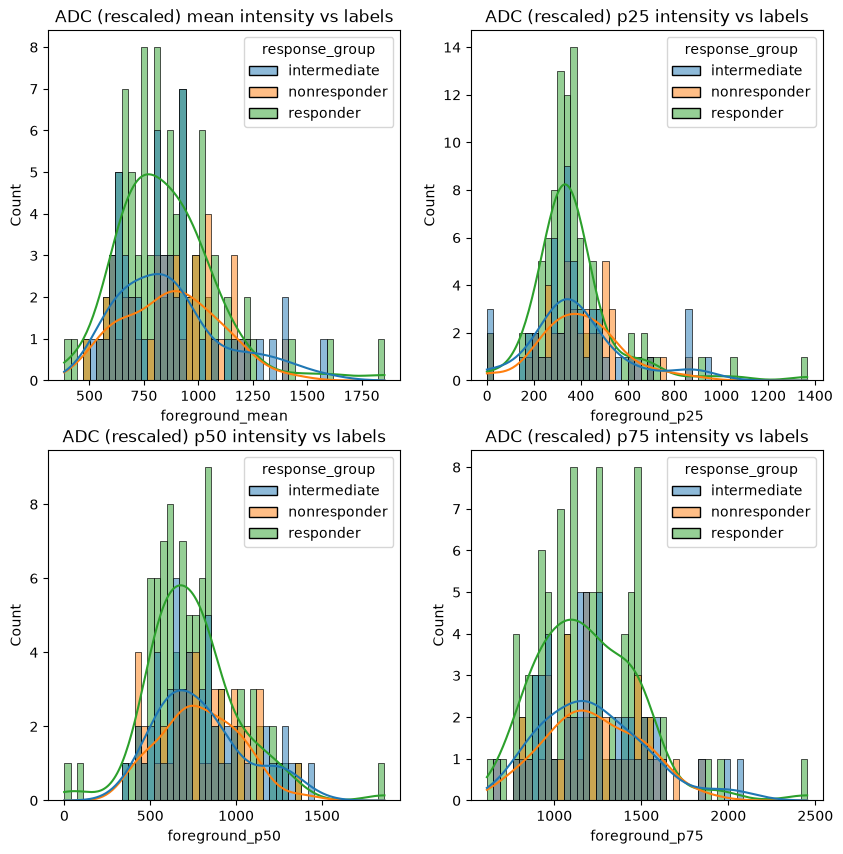

In [39]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=rescaled_df,
	x="foreground_mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=50
)
axes[0][0].set_title("ADC (rescaled) mean intensity vs labels")

sns.histplot(
	data=rescaled_df,
	x="foreground_p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=50
)
axes[0][1].set_title("ADC (rescaled) p25 intensity vs labels")

sns.histplot(
	data=rescaled_df,
	x="foreground_p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=50
)
axes[1][0].set_title("ADC (rescaled) p50 intensity vs labels")

sns.histplot(
	data=rescaled_df,
	x="foreground_p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=50
)
axes[1][1].set_title("ADC (rescaled) p75 intensity vs labels")

## Negative Valued ADC Imagings

I realized some ADC imagings have negative values. In reality, an ADC imaging **must not have any negative values.** I found out existance of negative values from the dataframe below (see ***"min"*** row):

In [ ]:
# adc_results: the dataframe with Intensity mean, median etc. values calculated
adc_results.describe()

,foreground_count,foreground_mean,foreground_std,foreground_p01,foreground_p05,foreground_p25,foreground_p50,foreground_p75,foreground_p95,foreground_p99,...,tumor_p01,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis
count,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,...,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,9.106867e+05,774.019362,541.547881,37.353023,109.112362,355.539011,686.101847,1062.176629,1820.118966,2453.153921,...,534.680715,632.176455,780.968133,906.919885,1050.339844,1283.205864,1462.035250,269.371711,0.611187,0.998518
std,4.809970e+05,358.083270,246.797712,76.665446,119.365152,215.890287,342.538032,475.872531,861.412555,1069.218012,...,306.724017,347.213013,425.751597,501.532283,580.368557,694.705714,774.656115,197.981515,0.463003,1.387232
min,1.759790e+05,0.383890,0.340561,-1.000000,-1.000000,-1.000000,-0.001284,0.680002,1.135584,1.473008,...,0.354491,0.478975,0.555897,0.611011,0.701017,0.996293,1.264807,0.145120,-0.791353,-1.494428
25%,6.331450e+05,644.081595,432.968193,14.000000,67.000000,273.500000,543.000000,917.000000,1410.500000,2048.000000,...,418.520000,504.050000,613.500000,695.500000,796.500000,956.400000,1102.240000,156.000000,0.336158,-0.001583
50%,7.713920e+05,814.763082,564.607387,28.000000,96.000000,340.000000,701.000000,1120.000000,1841.000000,2655.000000,...,539.920000,625.000000,778.000000,886.000000,1028.000000,1260.150000,1433.390000,240.000000,0.619725,0.666028
75%,1.035282e+06,973.355582,690.350785,40.500000,123.500000,443.500000,854.000000,1356.500000,2362.000000,3112.500000,...,642.030000,750.525000,939.875000,1098.000000,1281.000000,1572.975000,1826.040000,337.000000,0.918564,1.567190
max,3.276784e+06,1854.572989,1146.200619,952.000000,1289.000000,1367.000000,1864.000000,2453.000000,4095.000000,4323.000000,...,1865.000000,2070.800000,2409.000000,2696.000000,2976.000000,3527.500000,3901.060000,1391.500000,2.132514,6.835700


Detect negative value containing samples:

In [71]:
# negative valued ADCs:
negative_adcs = []
negative_adc_patients_names = []
for sample_id, row in manifest_df.iterrows():
	if row["modality"] == "T2":
		continue
	image_path = get_abs_path(row["image_path"])
	image = sitk.ReadImage(image_path)
	image_array = sitk.GetArrayFromImage(image)
	finite = np.isfinite(image_array)
	neg_array_mean = (image_array[finite]<0).mean() 
	# print(len(neg_array))
	if neg_array_mean > 0:
		negative_adcs.append(sample_id)
		negative_adc_patients_names.append(row["patient_name"])


print(len(negative_adcs))
negative_adcs


25


['6da62ba89f121b65',
 '9209fbda98cda373',
 '003da9c17d67938b',
 'f2ee2155e8541645',
 '34457c052fa53b67',
 '8b579d8c7a2c7cd9',
 '9e594f345c74fecc',
 '9672ecc7488b9389',
 'c59b42edffd18083',
 'd27b47b4999b753a',
 '9d5fc7c15d1bd36e',
 '4ac9f924489ebdcc',
 '3c4e73d29e28261b',
 'b64f472cfa245fb4',
 '851ed2eba5a2c7be',
 'a77fe0fb06a7f625',
 '7e1a3b81d54dcd99',
 '411d55c74cb228ab',
 'c7a5674d74470e4b',
 'ecb432090f45b23e',
 'cdf0283adad9ec0f',
 '86a8c0bbd0ed5588',
 '1e31ba618d329376',
 'b4db08d61e37b729',
 'b3db4277dcb35da9']

In [72]:
negative_adc_patients_names

['CELIK, OSMAN',
 'KOZIK, TUNCAY',
 'MERDIM, BURHAN',
 'TASIMOVA, GULBARSHIN',
 'TUZ, GULSEN',
 'ANDELKOVIC, GORAN',
 'OZYURT, ASIYE',
 'RACHEV, NIKOLAY',
 'SIS, CEMAL',
 'AKBAS, EMINE MELEK',
 'GOK, KADRIYE',
 'SAFAROVA, ILAHA',
 'BUTUN, ASUR',
 'RASHIDOV, BAKHITZHAN',
 'YETIMLER, REMZIYE',
 'CALISKAN OZALP, BAHAR',
 'OBI, NDIBE JOSEPHAT',
 'ALIYEV, HASAN',
 'AYATA, EMINE',
 'BIGIRA, JOHN BOSCO',
 'CIFTCI, LEVENT',
 'ERGUNE, TELAT',
 'KOCYIGIT, GULFIDAN',
 'ORKUN, AYSEL',
 'TEZEL, OMER']

After checking randomly, I realized **negative values are backgrounds.** However, we need to prove this by checking tumor voxels as well, there must not any negative value exist there:

In [61]:
# negative valued Tumor ADCs:
negatives = []
for sample_id, row in manifest_df.iterrows():
	if row["modality"] == "T2":
		continue
	image_path = get_abs_path(row["image_path"])
	image = sitk.ReadImage(image_path)
	image_array = sitk.GetArrayFromImage(image)

	mask_path = get_abs_path(row["mask_path"])
	mask = sitk.ReadImage(mask_path)
	mask_array = sitk.GetArrayFromImage(mask)

	if image_array.shape != mask_array.shape:
		print("shape mismatch: ", sample_id)
		continue

	finite = np.isfinite(image_array)

	tumor_mask = (
        np.isfinite(mask_array)
        & (mask_array != 0)
    )
	valid_tumor = finite & tumor_mask
	tumor_values = image_array[valid_tumor]

	finite_mask = np.isfinite(image_array)
	finite = image_array[finite_mask]
	tumor = finite[mask_array]

	negative_fraction = (tumor_values < 0).mean()

	if negative_fraction > 0:
		negatives.append({
			"sample_id": sample_id,
			"negative_fraction": negative_fraction,
			"negative_count": np.count_nonzero(tumor_values < 0),
			"tumor_count": tumor_values.size
		})

shape mismatch:  2fa95f062483ba1b


In [62]:
print(len(negatives))
negatives

2


[{'sample_id': '9d5fc7c15d1bd36e',
  'negative_fraction': np.float64(0.0001177301624676242),
  'negative_count': np.int64(1),
  'tumor_count': 8494},
 {'sample_id': '3c4e73d29e28261b',
  'negative_fraction': np.float64(0.00021848372296263927),
  'negative_count': np.int64(1),
  'tumor_count': 4577}]

Unfortunately, **seems like most negative value containing imagings contains negatives on random voxels.** This might still be acceptable when mean intensity is too high (like +500) but negatives are in interval [-1, 0]. for 25 negative values samples, we should compare the avg. of all voxels and avg. of negative voxels:

In [73]:
negative_comparison_list = []

for sample_id in negative_adcs:
	row = manifest_df.loc[sample_id]
	image_path = get_abs_path(row["image_path"])
	image = sitk.ReadImage(image_path)
	image_array = sitk.GetArrayFromImage(image)

	finite_mask = np.isfinite(image_array)
	negative_mask = image_array < 0

	all_img_mean = image_array[finite_mask].mean()

	negative_mean = image_array[(finite_mask & negative_mask)].mean()

	negative_comparison_list.append({
		"patient name":row["patient_name"],
		"all_mean":all_img_mean,
		"neg_mean":negative_mean
	})



In [74]:
negative_comparison_df = pd.DataFrame(negative_comparison_list)
negative_comparison_df

,patient name,all_mean,neg_mean
0,"CELIK, OSMAN",0.862208,-0.022869
1,"KOZIK, TUNCAY",668.895238,-1.000000
2,"MERDIM, BURHAN",0.940643,-0.039602
3,"TASIMOVA, GULBARSHIN",0.745385,-0.035191
4,"TUZ, GULSEN",0.586931,-0.122344
5,"ANDELKOVIC, GORAN",618.016707,-1.000000
6,"OZYURT, ASIYE",0.722461,-0.174851
7,"RACHEV, NIKOLAY",0.863571,-0.031087
8,"SIS, CEMAL",0.856832,-0.139163
9,"AKBAS, EMINE MELEK",271.686345,-256.000000


**Caution:** Two imagins has **incredibly high negative means**, -256. Fortunately, I checked them manually on 3d Slicer and they are just background. Can be zeroed easily.

My conclusion from here is, just **zero the negatives straight**.

In [84]:
os.makedirs("non_neg_adc", exist_ok=True)
adc_non_neg_intensities_list = []
for sample_id, row in manifest_df[manifest_df["modality"] == "ADC"].iterrows():
	# read image
	image_path = get_abs_path(row["image_path"])
	image = sitk.ReadImage(image_path)
	image_array = sitk.GetArrayFromImage(image).astype(np.float32)

	# create finite mask
	finite_mask = np.isfinite(image_array)

	# create negative mask (3D)
	negative_mask = (image_array < 0)

	# zero all negative values
	image_array[negative_mask] = 0

	# use finite mask (1D)
	image_array[~finite_mask] = 0
	valid_image = image_array[finite_mask]

	# calc mean
	mean = valid_image.mean()

	# calc percentiles
	percentiles = np.percentile(
		valid_image,
		[25, 50, 75, 99]
	)

	p25, p50, p75, p99 = percentiles

	# if small units image, multiply results x1000	
	if p99 < 10:
		mean *= 1000
		p25 *= 1000
		p50 *= 1000
		p75 *= 1000
		image_array *= 1000

	adc_non_neg_intensities_list.append({
		"response_group":row["response_group"],
		"mean":mean,
		"p25": p25,
		"p50": p50,
		"p75": p75,
	})

	final_image = sitk.GetImageFromArray(image_array)
	final_image.CopyInformation(image)

	sitk.WriteImage(final_image, f"non_neg_adc/{row["patient_name"]}.nrrd")


In [82]:
adc_non_neg_intensities_df = pd.DataFrame(adc_non_neg_intensities_list)
adc_non_neg_intensities_df.head()

,response_group,mean,p25,p50,p75
0,intermediate,274.265785,0.0,0.0,472.0
1,intermediate,878.815263,11.0,661.0,1256.0
2,intermediate,291.570456,0.0,0.0,487.0
3,intermediate,1121.340985,528.0,1179.0,1543.0
4,intermediate,289.188864,0.0,0.0,555.0


Text(0.5, 1.0, 'ADC (non-negative + rescaled) p75 intensity vs labels')

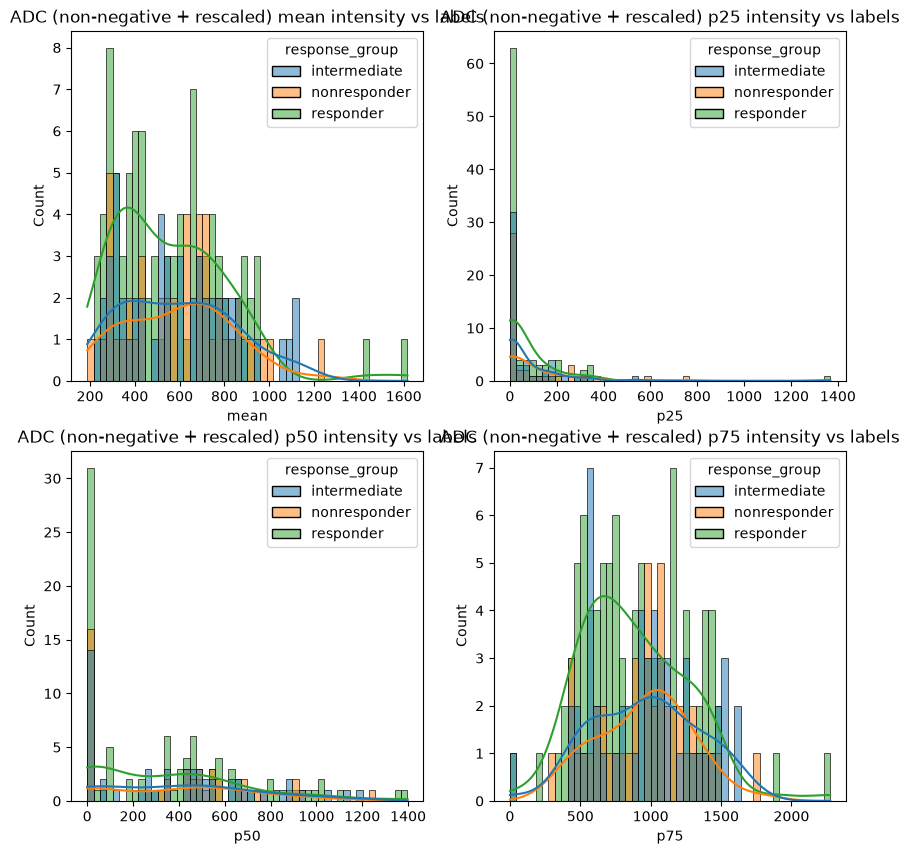

In [83]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=adc_non_neg_intensities_df,
	x="mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=50
)
axes[0][0].set_title("ADC (non-negative + rescaled) mean intensity vs labels")

sns.histplot(
	data=adc_non_neg_intensities_df,
	x="p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=50
)
axes[0][1].set_title("ADC (non-negative + rescaled) p25 intensity vs labels")

sns.histplot(
	data=adc_non_neg_intensities_df,
	x="p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=50
)
axes[1][0].set_title("ADC (non-negative + rescaled) p50 intensity vs labels")

sns.histplot(
	data=adc_non_neg_intensities_df,
	x="p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=50
)
axes[1][1].set_title("ADC (non-negative + rescaled) p75 intensity vs labels")

From mean graph, we can see all imagings are distributed naturally. In other graphs many zeros might seem dangerous but they are not, because they are percentiles and thanks to how big the background is, all most of the imagins just have large zero areas all over their surfaces. **After random manual check on 3D Slicer, I approve the images are fine.**

**CONCLUSION:** Intensities are very very imbalanced, a normalization is necessary. T2 and ADC modalities are different in meaningful domains, and should be normalized differently:

**T2:** Apply z-score normalization to each sample, with mean=0, std=1. **After normalization, there is no clear seperation between reponse groups.**

**ADC:** ADC modality should not be normalized, as the values are meaningful as they are. But appearently, when imaging done, a unit scale difference happened. This is not a normalization but small scaled images should be rescaled to scale of other imagings. **Tested and analyzed carefully and decided on rescaling small scaled imagins x1000, this seems the natural way to process them.**